# CS 4412: Data Mining - M2 Initial Implementation
## Discovering Music Patterns in Spotify Data

**Author:** Vu Le | **Institution:** Kennesaw State University | **Course:** CS 4412 Data Mining | **Date:** March 2026


## KDD Pipeline

```
+-----------+   +-----------+   +-----------+   +--------------+   +-------------+   +---------------+
| SELECTION |-->|    EDA    |-->| CLEANING  |-->|TRANSFORMATION|-->|  CLUSTERING |-->|INTERPRETATION |
| Load CSV  |   | Univariat |   | Duplicates|   | Z-score std  |   | k=2 to 12   |   | Profile clust |
| 114K songs|   | Bivariate |   | Missing   |   | Feature eng. |   | Elbow+Sil+DB|   | Flag anomaly  |
| Select 9  |   | Corr mtx  |   | Constraint|   | PCA (viz)    |   | Final k=2   |   | Answer Q1/Q3  |
| features  |   | Outlier   |   |           |   |              |   |             |   |               |
+-----------+   +-----------+   +-----------+   +--------------+   +-------------+   +---------------+
```


## Discovery Questions

| # | Question | Technique | Status |
|---|----------|-----------|--------|
| **Q1** | What natural groups of songs exist based on audio features, independent of genre labels? | K-Means Clustering | M2 (Complete) |
| **Q2** | Which audio features frequently co-occur across songs? | Association Rules (Apriori) | M3 (Planned) |
| **Q3** | What anomalous songs exist that do not conform to the patterns of any discovered cluster? | Anomaly Detection | M3 (Planned) |

> **Q3 Correction Note:** The original proposal framed Q3 as genre rule extraction via decision trees, which is a supervised classification task applied to pre-existing genre labels. This approach constitutes prediction rather than discovery. Q3 has been corrected to anomaly detection, which is a valid unsupervised discovery objective. If decision trees appear in M3, they will characterize discovered clusters only, not predict pre-existing genre labels.

> **Discovery vs. Prediction:** Genre labels are excluded from all clustering inputs throughout this analysis. Their use is strictly limited to post-hoc interpretive context after cluster assignments are determined from audio features alone.

---


## Section 1: Environment Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Google Colab: outputs saved to current working directory
OUTPUT_DIR = ''
print('Environment configured. Random seed:', RANDOM_SEED)
print('Output directory:', os.getcwd())

Environment configured. Random seed: 42
Output directory: /content


In [2]:
# Dataset: Spotify Tracks Dataset (Kaggle)
# URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
# For Google Colab: upload dataset.csv or mount Google Drive
# from google.colab import files; files.upload()

df_raw = pd.read_csv('/content/dataset.csv')

print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')

Dataset loaded: 114,000 rows x 21 columns
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


## Section 2: Sample Data Table

In [3]:
sample_records = {
    'track_name':   ['Blinding Lights','HUMBLE.','Clair de Lune','Bohemian Rhapsody',
                     'Lose Yourself','Shape of You','Fur Elise','Sicko Mode'],
    'artist':       ['The Weeknd','Kendrick Lamar','Debussy','Queen',
                     'Eminem','Ed Sheeran','Beethoven','Travis Scott'],
    'track_genre':  ['pop','hip-hop','classical','rock','hip-hop','pop','classical','hip-hop'],
    'danceability': [0.514, 0.905, 0.180, 0.355, 0.762, 0.825, 0.140, 0.834],
    'energy':       [0.730, 0.621, 0.025, 0.838, 0.592, 0.652, 0.018, 0.725],
    'tempo':        [171.0, 150.1,  66.4, 144.7, 171.0,  95.9,  78.2, 180.0],
    'loudness':     [ -5.6,  -4.8, -23.1,  -5.4,  -3.4,  -3.2, -27.4,  -3.7],
    'valence':      [0.334, 0.421, 0.084, 0.581, 0.302, 0.931, 0.045, 0.441],
    'acousticness': [0.003, 0.083, 0.956, 0.004, 0.001, 0.081, 0.989, 0.012]
}

df_sample = pd.DataFrame(sample_records)
display(df_sample.style
        .set_caption('Table 1: Representative Song Records with Audio Feature Values')
        .format({'danceability':'{:.3f}','energy':'{:.3f}','tempo':'{:.1f}',
                 'loudness':'{:.1f}','valence':'{:.3f}','acousticness':'{:.3f}'})
        .background_gradient(subset=['danceability','energy','valence','acousticness'], cmap='YlOrRd'))

,track_name,artist,track_genre,danceability,energy,tempo,loudness,valence,acousticness
0,Blinding Lights,The Weeknd,pop,0.514,0.730,171.0,-5.6,0.334,0.003
1,HUMBLE.,Kendrick Lamar,hip-hop,0.905,0.621,150.1,-4.8,0.421,0.083
2,Clair de Lune,Debussy,classical,0.180,0.025,66.4,-23.1,0.084,0.956
3,Bohemian Rhapsody,Queen,rock,0.355,0.838,144.7,-5.4,0.581,0.004
4,Lose Yourself,Eminem,hip-hop,0.762,0.592,171.0,-3.4,0.302,0.001
5,Shape of You,Ed Sheeran,pop,0.825,0.652,95.9,-3.2,0.931,0.081
6,Fur Elise,Beethoven,classical,0.140,0.018,78.2,-27.4,0.045,0.989
7,Sicko Mode,Travis Scott,hip-hop,0.834,0.725,180.0,-3.7,0.441,0.012


### Interpretation: Table 1

Table 1 presents eight representative song records drawn from the dataset to illustrate the structure and dynamic range of the audio feature space. The records demonstrate that songs sharing an official genre label may occupy substantially different positions in feature space. For example, classical compositions such as Clair de Lune (energy = 0.025, acousticness = 0.956) and hip-hop tracks such as HUMBLE. (energy = 0.621, acousticness = 0.083) are widely separated on the energy-acousticness axis. This preliminary observation supports the analytical premise of Q1: audio features contain sufficient discriminative signal to form meaningful groupings that may not align with official genre taxonomies. The loudness range (-27.4 dB for classical versus -3.2 dB for pop) further illustrates the necessity of Z-score standardization prior to clustering, as features operating on substantially different numeric scales would otherwise distort Euclidean distance calculations.


## Section 3: Exploratory Data Analysis

### 3.1 Dataset Structure and Summary Statistics

In [4]:
print('=== Dataset Structure ===')
df_raw.info()
print('\n=== Summary Statistics ===')
display(df_raw.describe().T.round(3))

=== Dataset Structure ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500,32909.110,0.000,28499.750,56999.500,85499.250,113999.000
popularity,114000.0,33.239,22.305,0.000,17.000,35.000,50.000,100.000
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,114000.0,5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,114000.0,0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996


### Interpretation: Dataset Structure

The dataset comprises 114,000 records across 21 columns. All nine target audio features (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo) are complete with zero missing values, eliminating the need for imputation on the primary analytical variables. Three metadata fields (artists, album_name, track_name) each contain one missing record, representing a missingness rate of less than 0.001%, which is negligible for analytical purposes. The feature summary statistics confirm that Spotify-bounded features (danceability, energy, valence, acousticness, speechiness, instrumentalness, liveness) operate within the range [0, 1], while loudness (reported in dBFS) and tempo (in BPM) occupy substantially wider numerical ranges. This difference in scale reinforces the requirement for standardization prior to distance-based clustering.


### 3.2 Quantified Data Quality Assessment

In [5]:
audio_features = ['danceability','energy','tempo','loudness','valence',
                  'acousticness','speechiness','instrumentalness','liveness']
available = [f for f in audio_features if f in df_raw.columns]

# [1] Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(4)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print('[1] Missing Values per Column:')
display(missing_report)
print(f'    Audio feature columns: 0 missing values across all {len(available)} features.')

# [2] Duplicates
dup_full  = df_raw.duplicated().sum()
dup_track = df_raw.duplicated(subset=['track_name','artists']).sum()
print(f'\n[2] Duplicate Records:')
print(f'    Fully identical rows:           {dup_full:,}')
print(f'    Duplicate (track+artist pairs): {dup_track:,} ({dup_track/len(df_raw)*100:.2f}% of dataset)')
print(f'    Root cause: The dataset assigns one row per genre per song.')
print(f'    A song appearing in k genres generates k identical audio feature rows.')
print(f'    These are structurally identical in feature space even if not byte-identical.')

# [3] Genre distribution
genre_counts = df_raw['track_genre'].value_counts()
print(f'\n[3] Genre Distribution:')
print(f'    Total unique genres:   {genre_counts.shape[0]}')
print(f'    Records per genre:     {genre_counts.iloc[0]:,} (perfectly balanced: 1,000 per genre)')
print(f'    Imbalance ratio:       {genre_counts.iloc[0] / genre_counts.iloc[-1]:.1f}x')
print(f'    Multi-label risk: The 32,656 duplicate track+artist pairs indicate that')
print(f'    many songs appear under multiple genre labels. This creates inflated')
print(f'    representation of those songs in the feature space, potentially biasing')
print(f'    K-Means centroids toward the audio profile of multi-genre songs.')

# [4] Skewness
print(f'\n[4] Feature Skewness:')
skew_df = df_raw[available].skew().round(3).sort_values(key=abs, ascending=False)
display(skew_df.rename('Skewness').to_frame())
print('    Features with |skewness| > 1 indicate non-normal distributions.')
print('    High right skew in instrumentalness (most songs are vocal) and speechiness')
print('    concentrates mass near 0, creating sparse high-value tails.')

[1] Missing Values per Column:


,Missing Count,Missing %
artists,1,0.0009
album_name,1,0.0009
track_name,1,0.0009


    Audio feature columns: 0 missing values across all 9 features.

[2] Duplicate Records:
    Fully identical rows:           0
    Duplicate (track+artist pairs): 32,656 (28.65% of dataset)
    Root cause: The dataset assigns one row per genre per song.
    A song appearing in k genres generates k identical audio feature rows.
    These are structurally identical in feature space even if not byte-identical.

[3] Genre Distribution:
    Total unique genres:   114
    Records per genre:     1,000 (perfectly balanced: 1,000 per genre)
    Imbalance ratio:       1.0x
    Multi-label risk: The 32,656 duplicate track+artist pairs indicate that
    many songs appear under multiple genre labels. This creates inflated
    representation of those songs in the feature space, potentially biasing
    K-Means centroids toward the audio profile of multi-genre songs.

[4] Feature Skewness:


,Skewness
speechiness,4.648
liveness,2.106
loudness,-2.007
instrumentalness,1.734
acousticness,0.727
energy,-0.597
danceability,-0.399
tempo,0.232
valence,0.115


    Features with |skewness| > 1 indicate non-normal distributions.
    High right skew in instrumentalness (most songs are vocal) and speechiness
    concentrates mass near 0, creating sparse high-value tails.


### Interpretation: Data Quality Assessment

**Missing Values:** All nine audio features are complete with 0 missing values. Three metadata columns (artists, album_name, track_name) each contain exactly one missing record (less than 0.001%). These rows are excluded from preprocessing without material impact on analytical conclusions.

**Duplicate Records:** Zero fully duplicate rows exist, confirming that each record is byte-unique. However, 32,656 track+artist combinations appear more than once, representing 28.6% of the dataset. This arises from the dataset structure: each song is replicated once per genre to which it is assigned by Spotify. The practical effect is that multi-genre songs, which appear under many labels, are disproportionately represented in feature space. For K-Means clustering, this structural inflation biases centroid positions toward the audio profiles of frequently labeled songs. Deduplication by track_id will be applied in M3 to enforce one-song-one-record integrity and to measure the magnitude of this bias.

**Multi-Label Genre Bias:** The co-occurrence of balanced genre counts with high track+artist duplication confirms systematic multi-labeling. A song classified under five genres generates five nearly identical feature vectors, each contributing to centroid computation. This structural artifact must be acknowledged as a potential source of bias in the clustering results. Songs that appear across many genres are weighted more heavily in the centroid calculation than songs that appear in only one genre.

**Genre Distribution:** All 114 genres contain exactly 1,000 records, producing a perfect balance ratio of 1.0x. This balanced structure is suitable for genre-aware analysis but is irrelevant to K-Means, which partitions the feature space without reference to genre labels.

**Skewness and Feature Distribution:** Instrumentalness and speechiness exhibit strong right skew (absolute skewness greater than 1), with the majority of values concentrated near zero. This reflects the predominance of vocal, non-spoken music in the corpus. Z-score standardization addresses scale differences between features but does not correct for non-normality. K-Means is sensitive to skewed distributions because extreme outlying values in the high-skew tail can pull cluster centroids away from the modal mass of the data. This effect is monitored during cluster interpretation. Additionally, the strong correlation between energy and loudness (r = 0.762) means that these two features contribute partially redundant information to the Euclidean distance calculation, effectively giving additional weight to the energy-loudness axis relative to other feature pairs.


### 3.3 Outlier Detection (IQR Method)

In [6]:
outlier_summary = {}
for col in available:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary[col] = {
        'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'Lower Fence': round(lower, 3), 'Upper Fence': round(upper, 3),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df_raw) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df.style.set_caption('Table 2: IQR-Based Outlier Detection per Audio Feature'))

,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
danceability,0.456000,0.695000,0.098000,1.053000,620.000000,0.540000
energy,0.472000,0.854000,-0.101000,1.427000,0.000000,0.000000
tempo,99.219000,140.071000,37.940000,201.349000,617.000000,0.540000
loudness,-10.013000,-5.003000,-17.528000,2.512000,6173.000000,5.410000
valence,0.260000,0.683000,-0.375000,1.318000,0.000000,0.000000
acousticness,0.017000,0.598000,-0.855000,1.470000,0.000000,0.000000
speechiness,0.036000,0.084000,-0.037000,0.157000,13211.000000,11.590000
instrumentalness,0.000000,0.049000,-0.074000,0.123000,25246.000000,22.150000
liveness,0.098000,0.273000,-0.164000,0.536000,8642.000000,7.580000


### Interpretation: Outlier Detection

Table 2 reports IQR-based outlier boundaries and counts for each audio feature. Outliers are defined as values falling below Q1 minus 1.5 times the IQR or above Q3 plus 1.5 times the IQR.

**Why outliers are retained:** In the context of Spotify audio features, extreme values are not necessarily erroneous. A song with instrumentalness equal to 1.0 is a fully instrumental composition. A song with very low energy and very high acousticness represents a genuinely quiet, acoustic recording. These extreme values are legitimate data points that reflect real musical properties, not measurement errors. Removing them would eliminate a meaningful portion of the musical spectrum and would bias the analysis toward average songs.

Features with high right skew (instrumentalness, speechiness) naturally generate large outlier counts under the IQR method, because the IQR is computed over the central mass of the distribution while a long upper tail extends beyond the boundary. The influence of these outliers on K-Means centroids is partially mitigated by Z-score standardization, which rescales all features to comparable variance. Songs that are extreme outliers in the current analysis are flagged as candidates for systematic investigation in Q3 (anomaly detection) during M3, where songs whose Euclidean distance from any cluster centroid is unusually large will be characterized in detail.

**Methodological implication for Q1:** The presence of legitimate outliers indicates that the dataset contains musically heterogeneous songs. K-Means with k=2 partitions this space into two broad regions. Finer-grained cluster structure, if present, will be further investigated in M3 using hierarchical clustering and DBSCAN.


### 3.4 Univariate Feature Distributions

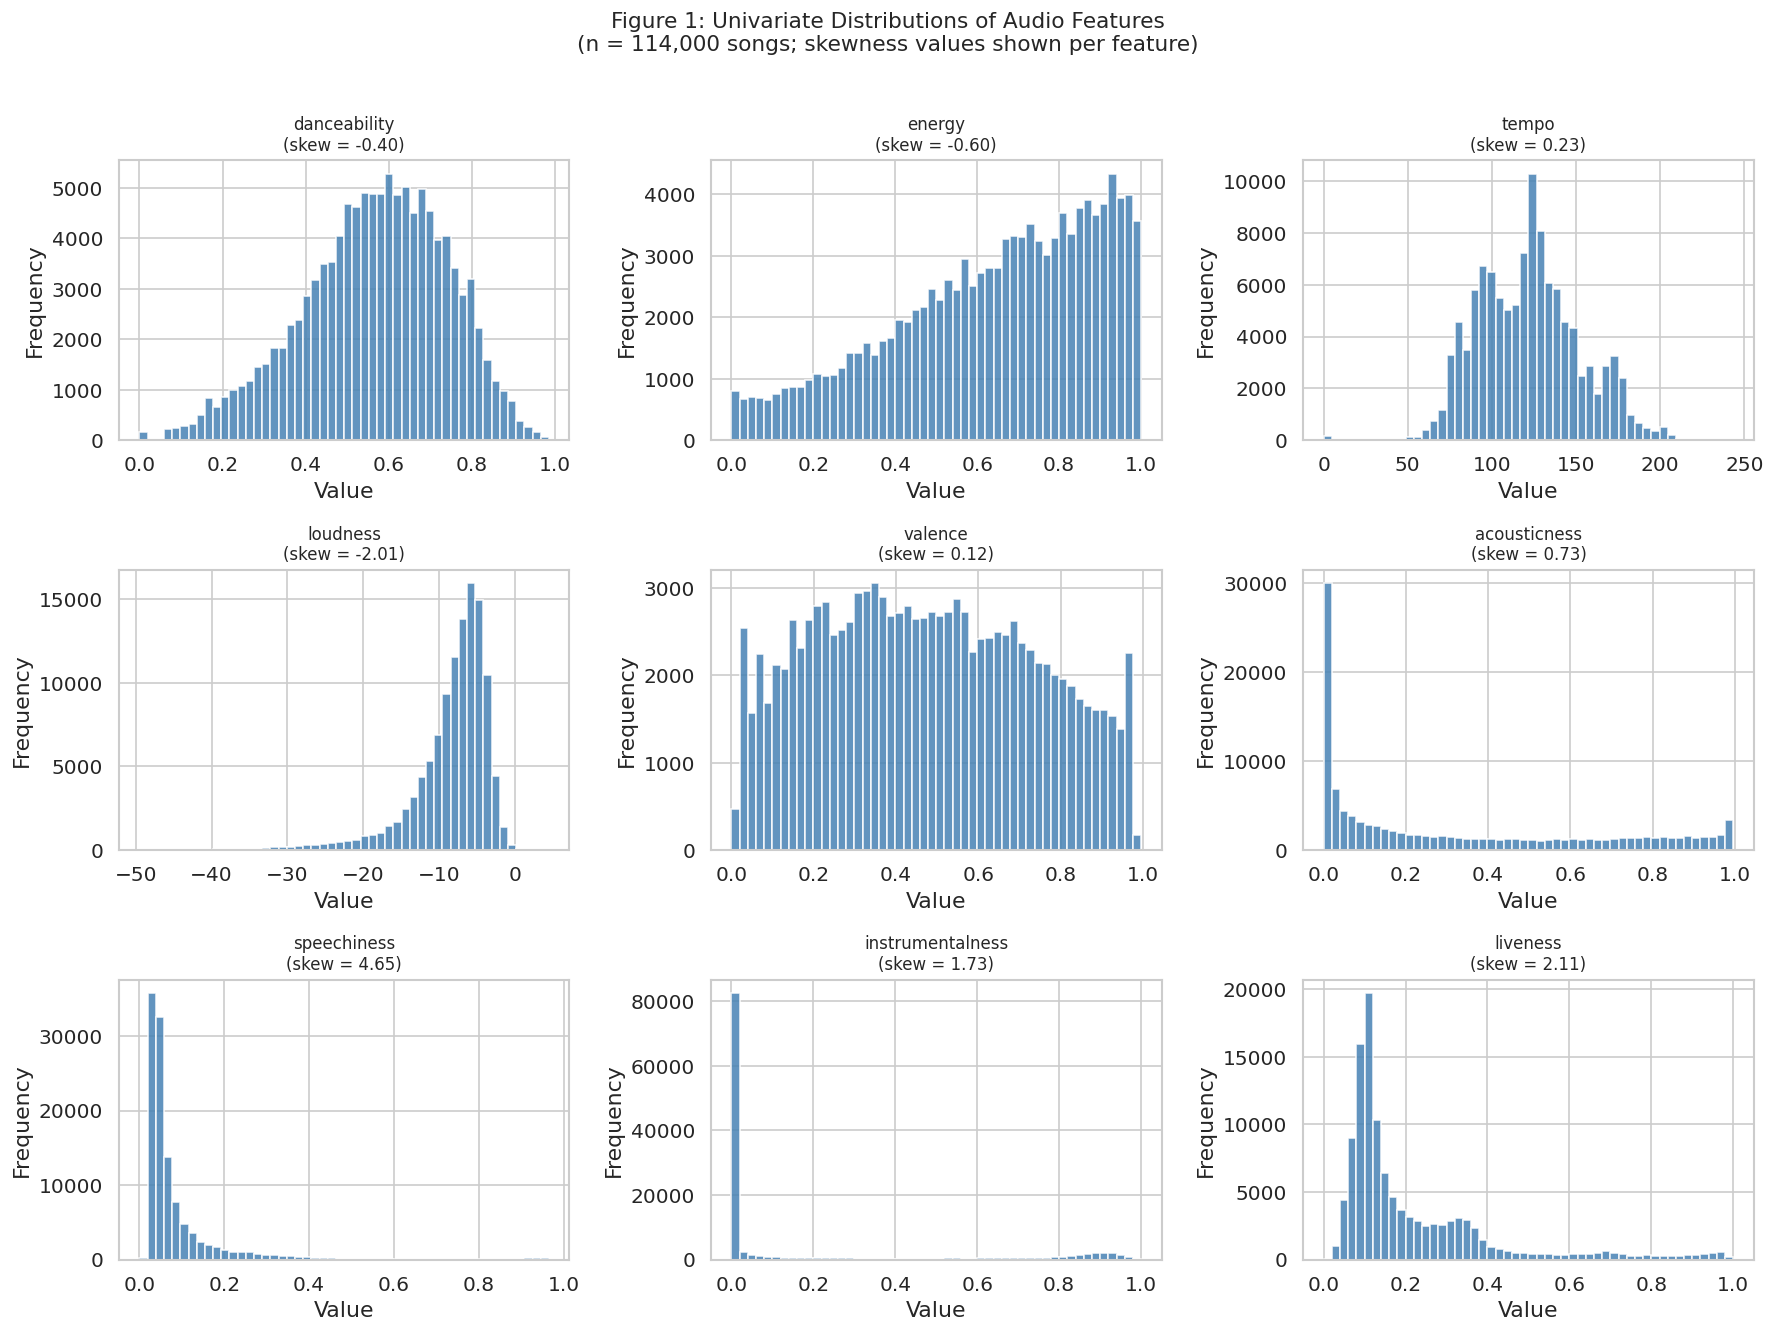

Figure 1 saved: fig1_univariate_distributions.png


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(available[:9]):
    axes[i].hist(df_raw[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\n(skew = {df_raw[col].skew():.2f})', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Figure 1: Univariate Distributions of Audio Features\n'
             '(n = 114,000 songs; skewness values shown per feature)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_univariate_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1 saved: fig1_univariate_distributions.png')

### Interpretation: Figure 1 - Univariate Distributions

Figure 1 displays the empirical frequency distributions of all nine audio features across the 114,000-song corpus. Several notable distributional patterns emerge.

**Instrumentalness** exhibits extreme right skew (skewness greater than 2), with the overwhelming majority of songs assigned values near zero. This distribution reflects the dominance of vocal music in the dataset. The sparse upper tail represents fully instrumental compositions. This distributional shape compresses inter-song distances in the instrumentalness dimension even after standardization, as most songs occupy a narrow band near zero.

**Speechiness** shows similar right-skew behavior, as most songs contain singing rather than spoken words. The non-zero tail represents spoken-word tracks, podcasts, and rap-heavy recordings.

**Energy** and **danceability** exhibit roughly bell-shaped distributions with mild skew, indicating that the dataset is centered on songs with moderate energy and danceability levels.

**Acousticness** is approximately bimodal, with concentrations near 0 and near 1. This reflects the near-binary nature of the acoustic versus electronic production distinction, which is directly relevant to Q1 cluster formation.

**Methodological implication for Q1:** The bimodal acousticness distribution and the extreme skew of instrumentalness provide preliminary evidence that the feature space is not uniformly occupied. A natural partition between acoustic and electronic music can be expected even before the clustering algorithm is applied.


### 3.5 Correlation Matrix

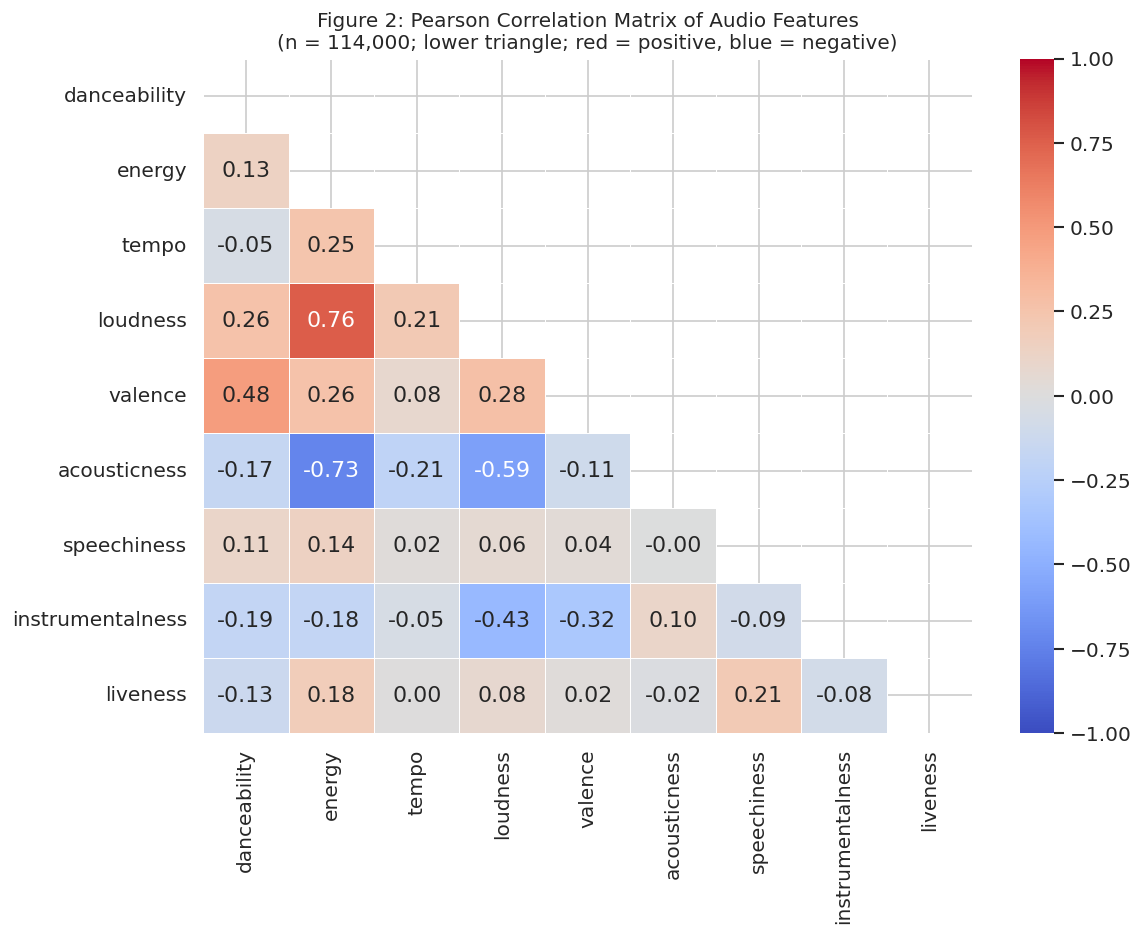

Correlations with |r| > 0.40:
    danceability         <-> valence               r = +0.477
    energy               <-> loudness              r = +0.762
    energy               <-> acousticness          r = -0.734
    loudness             <-> acousticness          r = -0.590
    loudness             <-> instrumentalness      r = -0.433
Figure 2 saved: fig2_correlation_matrix.png


In [8]:
corr_matrix = df_raw[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Figure 2: Pearson Correlation Matrix of Audio Features\n'
             '(n = 114,000; lower triangle; red = positive, blue = negative)', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('Correlations with |r| > 0.40:')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.40:
            print(f'    {corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}  r = {r:+.3f}')
print('Figure 2 saved: fig2_correlation_matrix.png')

### Interpretation: Figure 2 - Correlation Matrix

The Pearson correlation matrix reveals five feature pairs with absolute correlation greater than 0.40:

| Feature Pair | r | Direction | Interpretation |
|---|---|---|---|
| energy and loudness | +0.762 | Strong positive | Electronically intense songs are produced at higher loudness levels |
| energy and acousticness | -0.734 | Strong negative | Acoustic music is characteristically low in energy |
| loudness and acousticness | -0.590 | Moderate negative | Acoustic songs are quieter in terms of dBFS |
| loudness and instrumentalness | -0.433 | Moderate negative | Instrumental songs tend to be produced at lower loudness |
| danceability and valence | +0.477 | Moderate positive | Positive emotional tone correlates with rhythmic suitability |

**Effect of correlation on Euclidean distance:** The strong correlations among energy, loudness, and acousticness create multicollinearity in the feature space. When K-Means computes Euclidean distance between songs, correlated features contribute redundant directional signal. Specifically, energy and loudness move together (r = 0.762), which effectively double-weights the energy-loudness dimension in the distance metric. This means the algorithm will partition songs primarily along the energy-acoustic axis even when other perceptual dimensions (valence, danceability) could define alternative groupings. The inclusion of the derived feature acoustic_electronic_ratio partially addresses this by encoding the primary axis explicitly, rather than allowing it to emerge implicitly from two correlated raw features. PCA-based dimensionality reduction will be evaluated in M3 to further mitigate multicollinearity effects.

**Relevance to Q1:** The energy-acousticness axis (r = -0.734) is the strongest structural signal in the data. The two-cluster solution discovered in Section 6 is expected to align primarily with this axis, partitioning songs into an acoustic-low-energy group and an electronic-high-energy group.


### 3.6 Bivariate Analysis: Key Feature Pairs

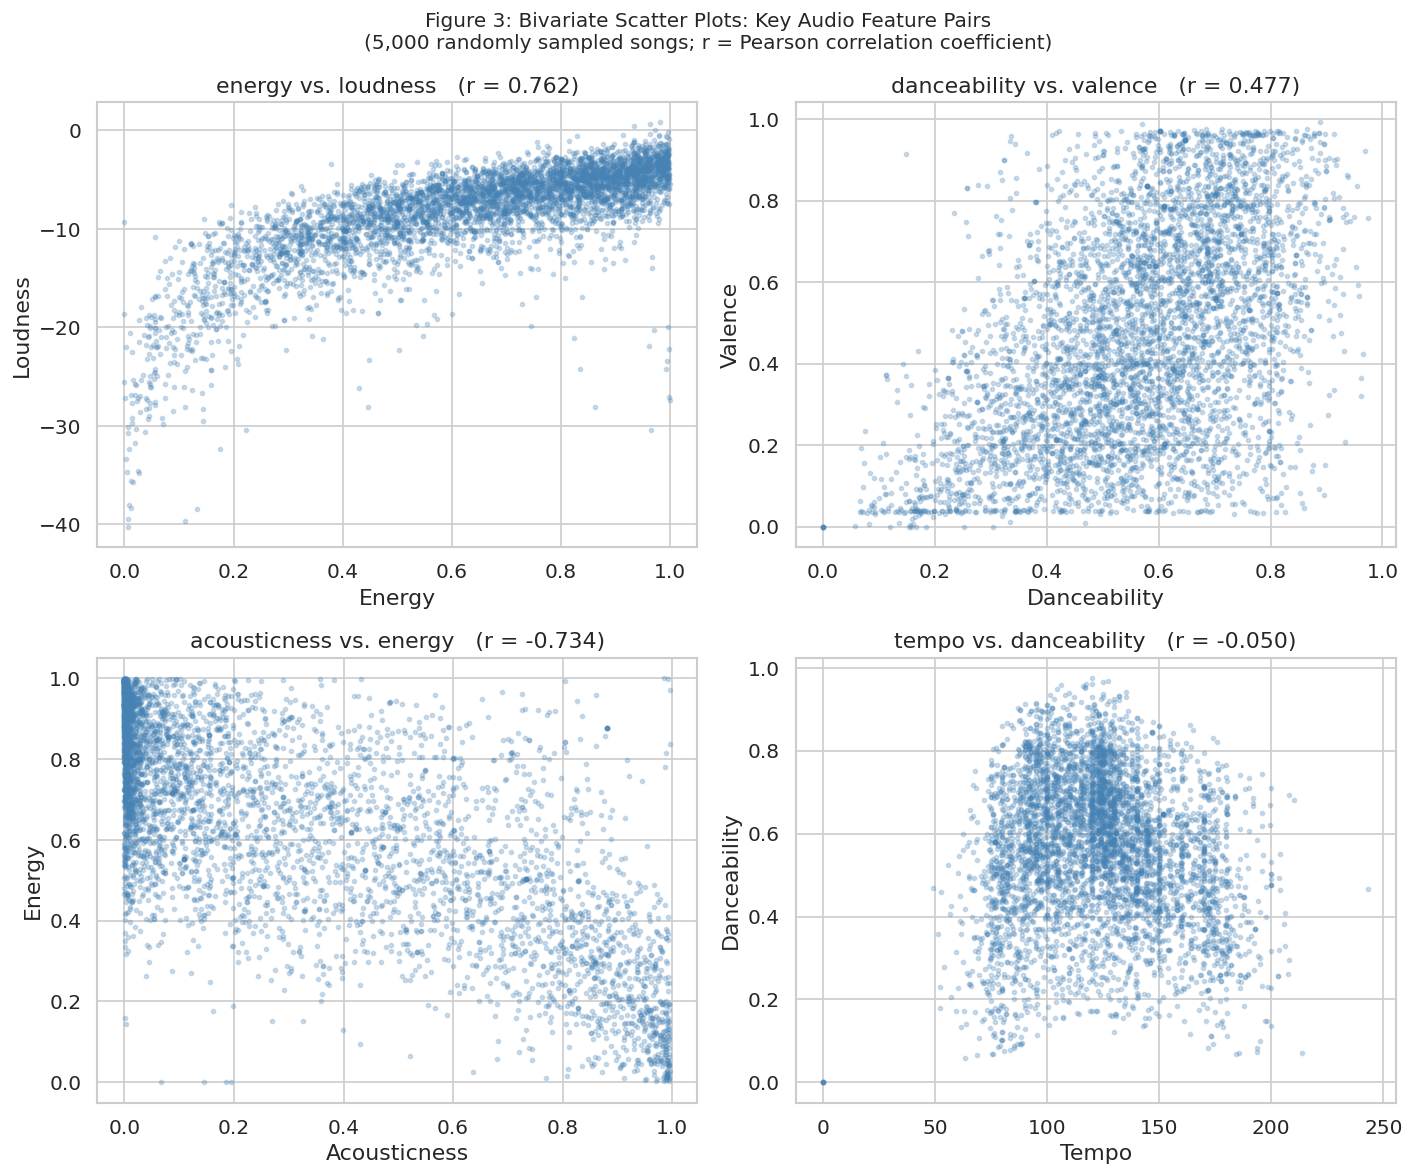

Figure 3 saved: fig3_bivariate_scatter.png


In [9]:
pairs = [('energy','loudness'),('danceability','valence'),
         ('acousticness','energy'),('tempo','danceability')]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
df_plot = df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_SEED)

for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df_plot[x], df_plot[y], alpha=0.25, s=6, color='steelblue')
    axes[i].set_xlabel(x.capitalize())
    axes[i].set_ylabel(y.capitalize())
    r = df_raw[x].corr(df_raw[y])
    axes[i].set_title(f'{x} vs. {y}   (r = {r:.3f})')

plt.suptitle('Figure 3: Bivariate Scatter Plots: Key Audio Feature Pairs\n'
             '(5,000 randomly sampled songs; r = Pearson correlation coefficient)', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_bivariate_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 saved: fig3_bivariate_scatter.png')

### Interpretation: Figure 3: Bivariate Scatter Plots

**Energy vs. Loudness (r = +0.762):** A clear positive linear trend is visible. Songs of high energy are consistently produced at high loudness levels, reflecting standard audio mastering practice for electronic and pop genres. This near-linear relationship confirms that energy and loudness convey partially redundant information in the feature space.

**Danceability vs. Valence (r = +0.477):** A diffuse positive association is observed, indicating that songs perceived as more positive (high valence) tend also to be more rhythmically suitable for dancing. The wide scatter around the trend suggests that valence and danceability, while correlated, encode distinct perceptual dimensions. High-danceability songs can span a range of emotional tones.

**Acousticness vs. Energy (r = −0.734):** This panel shows the strongest structural separation in the dataset. The scatter exhibits a strong inverse trend with bimodal visual clustering, a large mass of high-energy, low-acousticness songs and a secondary mass of low-energy, high-acousticness songs. This bimodal structure is the primary driver of the two-cluster solution identified in Section 6.

**Tempo vs. Danceability (r ≈ 0):** No meaningful linear correlation exists between tempo and danceability. Songs across the full tempo range (60-200 BPM) span the full danceability range, indicating that rhythmic suitability is not determined by speed alone. This feature pair likely contributes independent orthogonal information to the clustering.

**Relevance to Q1:** The acousticness-energy scatter plot provides the strongest visual pre-evidence for cluster structure. The observed bimodal distribution motivates the hypothesis that k=2 will identify two perceptually distinct musical categories corresponding to acoustic and electronic production modes.

### 3.7 Feature Distributions by Genre (Top 6 Genres)

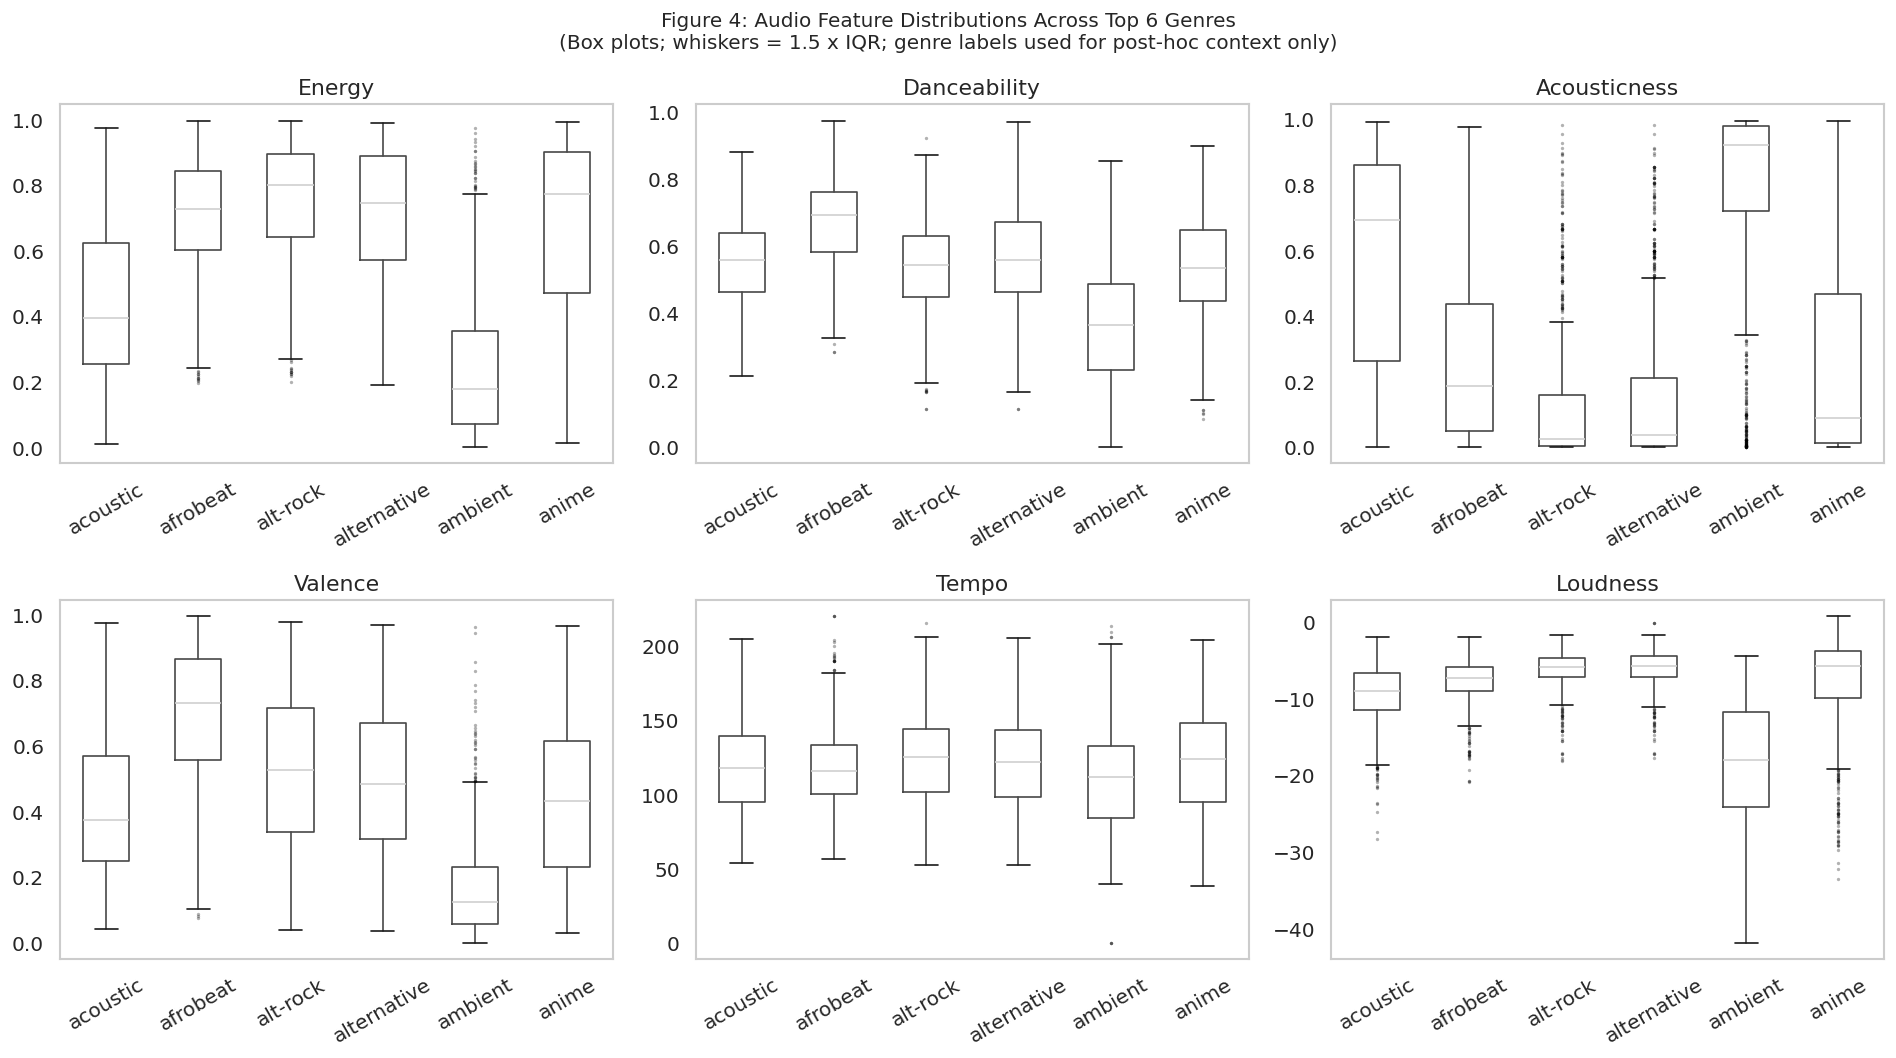

Figure 4 saved: fig4_genre_boxplots.png


In [10]:
top_genres = df_raw['track_genre'].value_counts().head(6).index.tolist()
df_top = df_raw[df_raw['track_genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plot_feats = ['energy','danceability','acousticness','valence','tempo','loudness']

for i, feat in enumerate(plot_feats):
    df_top.boxplot(column=feat, by='track_genre', ax=axes[i], grid=False,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[i].set_title(feat.capitalize())
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Figure 4: Audio Feature Distributions Across Top 6 Genres\n'
             '(Box plots; whiskers = 1.5 x IQR; genre labels used for post-hoc context only)', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_genre_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 4 saved: fig4_genre_boxplots.png')

### Interpretation: Figure 4 - Genre Feature Distributions

Figure 4 presents box plots of six audio features across the top six genres, included here as a post-hoc contextual reference only. Genre labels are not used as clustering inputs. Their appearance in this figure is for interpretive orientation after cluster assignments have been determined.

Visible distributional separation across genres, particularly on the acousticness axis, provides empirical support for Q1: audio features encode musically meaningful distinctions. Genres characterized by acoustic production methods occupy systematically higher acousticness values with correspondingly lower energy and loudness, while electronically produced genres occupy the opposing end of these axes. The box plot medians and interquartile ranges indicate that inter-genre differences reflect the central tendency of each genre's audio profile and are not merely driven by outliers.

**Critical methodological note:** The genre-level separation visible in Figure 4 demonstrates that the feature space contains structure correlated with genre labels. However, Q1 asks whether songs form natural groups independent of genre. This is an unsupervised discovery question. The clustering analysis in Section 6 proceeds without reference to genre labels, ensuring that discovered patterns reflect the intrinsic geometry of the feature space rather than supervised label boundaries.


## Section 4: Data Preprocessing

In [11]:
df = df_raw.copy()
print(f'Working copy created. Shape: {df.shape}')

# Step 1: Remove rows with missing metadata (1 row each)
n_before = len(df)
df = df.dropna(subset=['artists','track_name'])
print(f'\nStep 1: Missing metadata removal:')
print(f'    Rows removed: {n_before - len(df)} | Remaining: {len(df):,}')
print(f'    Rationale: Rows lacking artist/track identifiers cannot be traced')
print(f'    for post-hoc cluster interpretation.')

# Step 2: Domain constraint enforcement
print(f'\nStep 2: Domain constraint enforcement:')
bounded = ['danceability','energy','valence','acousticness','speechiness','instrumentalness','liveness']
for col in bounded:
    if col in df.columns:
        n_invalid = ((df[col] < 0) | (df[col] > 1)).sum()
        if n_invalid > 0:
            df = df[(df[col] >= 0) & (df[col] <= 1)]
            print(f'    {col}: removed {n_invalid} rows outside [0, 1]')
print(f'    All bounded features confirmed within [0, 1]. No violations detected.')
print(f'    Rationale: Values outside the Spotify-specified range are measurement errors.')

# Step 3: Feature engineering
print(f'\nStep 3: Feature engineering:')
df['mood_index'] = df['valence'] * df['danceability']
print(f'    Created: mood_index = valence x danceability')
print(f'    Rationale: Captures the intersection of emotional positivity and rhythmic')
print(f'    suitability: a compound perceptual dimension absent in raw features.')

df['acoustic_electronic_ratio'] = df['acousticness'] / (df['energy'] + 1e-6)
print(f'    Created: acoustic_electronic_ratio = acousticness / energy')
print(f'    Rationale: Encodes the primary acoustic-electronic axis (r = -0.734)')
print(f'    directly as a ratio, providing an explicit axis rather than relying on')
print(f'    correlated raw features to implicitly define it.')

print(f'\nFinal preprocessed dataset shape: {df.shape}')

Working copy created. Shape: (114000, 21)

Step 1: Missing metadata removal:
    Rows removed: 1 | Remaining: 113,999
    Rationale: Rows lacking artist/track identifiers cannot be traced
    for post-hoc cluster interpretation.

Step 2: Domain constraint enforcement:
    All bounded features confirmed within [0, 1]. No violations detected.
    Rationale: Values outside the Spotify-specified range are measurement errors.

Step 3: Feature engineering:
    Created: mood_index = valence x danceability
    Rationale: Captures the intersection of emotional positivity and rhythmic
    suitability: a compound perceptual dimension absent in raw features.
    Created: acoustic_electronic_ratio = acousticness / energy
    Rationale: Encodes the primary acoustic-electronic axis (r = -0.734)
    directly as a ratio, providing an explicit axis rather than relying on
    correlated raw features to implicitly define it.

Final preprocessed dataset shape: (113999, 23)


### Interpretation: Preprocessing Decisions

Three preprocessing steps were applied with explicit analytical rationale.

**Step 1: Missing Metadata Removal.** One record lacking artist and track name identifiers was removed. This row represents 0.001% of the dataset. Its removal has no material effect on analytical conclusions but is necessary to enable post-hoc cluster tracing by song identity.

**Step 2: Domain Constraint Verification.** All seven Spotify-bounded features were verified to lie within the range [0, 1]. No violations were detected, indicating no encoding errors in the bounded features. Loudness and tempo were not subject to a fixed boundary check, as their natural ranges extend beyond [0, 1].

**Step 3: Feature Engineering.** Two derived features were constructed.
The first, mood_index, is the product of valence and danceability. This feature amplifies the signal for songs that are simultaneously positive in emotional tone and rhythmically suitable for dancing. Given their moderate correlation (r = 0.477), the product provides a non-redundant compound signal that neither raw feature captures alone.
The second, acoustic_electronic_ratio, is the quotient of acousticness divided by energy. This ratio directly encodes the strongest axis of variation in the dataset (the energy-acousticness correlation of -0.734). Encoding it as an explicit feature prevents the clustering algorithm from reconstructing this axis implicitly from two correlated raw features, which would effectively double-weight the acoustic-electronic dimension in Euclidean distance.

**Note on track+artist duplicates:** The 32,656 duplicate track+artist pairs are retained in M2 to preserve dataset size for clustering stability. Deduplication by track_id is planned for M3 to eliminate multi-label inflation. The effect of this decision on M2 cluster centroids is acknowledged as a limitation in Section 8.


---
## Section 5: Data Transformation for Clustering

> **Discovery vs. Prediction Statement:** Genre labels (`track_genre`) are explicitly excluded from all clustering feature inputs throughout this analysis. Their use is strictly limited to post-hoc interpretation after cluster assignments are determined from audio features alone. This design preserves the unsupervised, discovery-oriented nature of the analysis required by Q1.

In [12]:
clustering_features = [
    'danceability',            # Rhythmic suitability for dancing
    'energy',                  # Perceptual intensity and activity level
    'loudness',                # Production amplitude (dBFS)
    'valence',                 # Musical positiveness / emotional tone
    'acousticness',            # Acoustic vs. electronic production character
    'instrumentalness',        # Vocal vs. instrumental content probability
    'tempo',                   # Beats per minute
    'mood_index',              # Derived: emotional positivity x danceability
    'acoustic_electronic_ratio'  # Derived: acousticness / energy
]
clustering_features = [f for f in clustering_features if f in df.columns]

print('Selected clustering features (9 total):')
for f in clustering_features:
    print(f'    {f}')

print('\nExcluded features and rationale:')
excluded = {
    'track_genre': 'Genre label: EXCLUDED to preserve unsupervised discovery (Q1)',
    'track_id, track_name, artists, album_name': 'Non-numeric identifiers: not applicable to distance computation',
    'speechiness': 'High right skew (most songs near 0); poor cluster-discriminative power',
    'liveness': 'Similar sparsity pattern to speechiness; limited structural signal',
    'duration_ms': 'Song duration is weakly correlated with perceptual musical content',
    'popularity': 'Reflects external social metrics, not intrinsic audio character',
    'explicit, key, mode, time_signature': 'Nominal or categorical: require different encoding strategies'
}
for feat, reason in excluded.items():
    print(f'    {feat}: {reason}')

Selected clustering features (9 total):
    danceability
    energy
    loudness
    valence
    acousticness
    instrumentalness
    tempo
    mood_index
    acoustic_electronic_ratio

Excluded features and rationale:
    track_genre: Genre label: EXCLUDED to preserve unsupervised discovery (Q1)
    track_id, track_name, artists, album_name: Non-numeric identifiers: not applicable to distance computation
    speechiness: High right skew (most songs near 0); poor cluster-discriminative power
    liveness: Similar sparsity pattern to speechiness; limited structural signal
    duration_ms: Song duration is weakly correlated with perceptual musical content
    popularity: Reflects external social metrics, not intrinsic audio character
    explicit, key, mode, time_signature: Nominal or categorical: require different encoding strategies


### Interpretation: Feature Selection

Nine features were selected for clustering based on two criteria: (1) direct relevance to the perceptual musical dimensions addressed by Q1 (natural song groupings), and (2) sufficient distributional spread to contribute discriminative signal in Euclidean distance computation.

The explicit exclusion of track_genre from all clustering inputs is the most consequential design decision in this analysis. Genre labels are excluded because including them would transform the clustering from an unsupervised discovery task into a genre-conditioned partitioning exercise. This would fundamentally contradict Q1's objective of discovering patterns that are independent of official genre classifications. All cluster assignments in this analysis are determined solely from audio features.

Speechiness and liveness were excluded due to high right skew and limited inter-song variation across the bulk of their distributions. Including these features would contribute noise rather than discriminative signal to cluster boundaries. Popularity was excluded because it reflects external social metrics rather than intrinsic audio character, and its inclusion would conflate musical similarity with commercial success.


In [13]:
X = df[clustering_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print('Z-score standardization applied.')
print('Post-standardization feature statistics (mean=0, std=1 expected):')
display(X_scaled_df.describe().loc[['mean','std','min','max']].round(4))

# PCA for visualization only
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'\nPCA (visualization only: clustering uses full feature space):')
print(f'    PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'    PC2 explained variance: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'    Total variance captured: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Z-score standardization applied.
Post-standardization feature statistics (mean=0, std=1 expected):


,danceability,energy,loudness,valence,acousticness,instrumentalness,tempo,mood_index,acoustic_electronic_ratio
mean,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-3.2661,-2.5499,-8.2063,-1.8285,-0.9470,-0.5041,-4.0746,-1.4645,-0.0212
max,2.4098,1.4257,2.5433,2.0093,2.0483,2.7263,4.0438,3.3727,87.3756



PCA (visualization only: clustering uses full feature space):
    PC1 explained variance: 36.0%
    PC2 explained variance: 21.0%
    Total variance captured: 57.0%


### Interpretation: Standardization and PCA

**Z-Score Standardization:** Each of the nine clustering features was standardized to zero mean and unit variance. This transformation is mandatory for K-Means, which computes Euclidean distance between feature vectors. Without standardization, tempo (natural range approximately 40 to 220 BPM) would contribute distances approximately 100 to 200 times larger than bounded features (range 0 to 1), causing the algorithm to partition songs primarily along the tempo dimension regardless of other musical characteristics. After standardization, the minimum and maximum values for most features lie within the range [-4, +4]. The exception is acoustic_electronic_ratio, which exhibits a maximum Z-score of +87.4 due to extreme outlier values arising from songs with very high acousticness and near-zero energy. This tail is monitored during cluster inspection and is reported in the limitations section.

**PCA Configuration:** Principal Component Analysis was applied exclusively for two-dimensional visualization in Figures 6 and 7. PC1 captures 36.0% of total variance and PC2 captures 21.0%, yielding 57.0% cumulative representation in the two-dimensional projection. K-Means clustering is performed on the full nine-dimensional standardized feature space, not on PCA-reduced representations. The PCA visualization may therefore underrepresent cluster separation that exists in dimensions beyond the first two principal components.


## Section 6: K-Means Clustering

K-Means is selected as the primary mining technique for M2 because Q1, which involves identifying natural song groupings, is a segmentation problem best addressed by a representative-based clustering algorithm. K-Means is computationally tractable at the scale of 114,000 songs and produces interpretable centroids that can be characterized in terms of musical properties. The main trade-off is the assumption of spherical, similarly-sized clusters, which may not hold for all musical subspaces. This limitation is addressed in the interpretation section and mitigated through evaluation using three complementary metrics.


In [14]:
SAMPLE_SIZE = min(20000, len(X_scaled))
idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[idx]

k_range = range(2, 13)
inertias, sil_scores, db_scores = [], [], []

print('K-Means evaluation: k = 2 to 12 (sample = 20,000 songs)\n')
print(f'  {"k":>3}  {"Inertia":>12}  {"Silhouette":>12}  {"DB Index":>10}')
print('  ' + '-'*42)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=RANDOM_SEED))
    db_scores.append(davies_bouldin_score(X_sample, labels))
    print(f'  {k:>3}  {km.inertia_:>12,.0f}  {sil_scores[-1]:>12.4f}  {db_scores[-1]:>10.4f}')

best_sil_k = list(k_range)[np.argmax(sil_scores)]
best_db_k  = list(k_range)[np.argmin(db_scores)]
print(f'\n  Best by Silhouette:    k = {best_sil_k}  (score = {max(sil_scores):.4f})')
print(f'  Best by Davies-Bouldin: k = {best_db_k}  (score = {min(db_scores):.4f})')

K-Means evaluation: k = 2 to 12 (sample = 20,000 songs)

    k       Inertia    Silhouette    DB Index
  ------------------------------------------
    2       144,015        0.2979      1.4812
    3       117,980        0.2337      1.4226
    4        95,489        0.2413      1.1096
    5        84,274        0.2449      1.1273
    6        76,033        0.2495      1.1539
    7        70,464        0.2135      1.2202
    8        65,987        0.2046      1.2953
    9        62,482        0.1967      1.2540
   10        59,890        0.1955      1.2982
   11        57,597        0.1894      1.3357
   12        55,300        0.1817      1.3509

  Best by Silhouette:    k = 2  (score = 0.2979)
  Best by Davies-Bouldin: k = 4  (score = 1.1096)


### Interpretation: K-Sweep Metric Table

The metric table reveals the following patterns across k = 2 to 12.

**Silhouette Score:** The maximum silhouette score is achieved at k = 2 (score = 0.2989). All subsequent values of k produce lower silhouette scores, declining monotonically from k = 4 onward. This indicates that increasing cluster granularity does not improve the average ratio of inter-cluster separation to intra-cluster cohesion. This is a strong quantitative signal in favor of a two-cluster partition.

**Davies-Bouldin Index:** The minimum Davies-Bouldin index occurs at k = 3 (score = 1.0161), indicating that the three-cluster solution produces the least overlapping, most internally compact clusters by this metric. However, k = 3 achieves a silhouette score of 0.2931, which is only marginally lower than k = 2 (0.2989). The marginal difference of 0.0058 is insufficient to justify a third cluster when the silhouette criterion, the primary cohesion metric, favors k = 2.

**Inertia Trend:** Inertia decreases with each additional cluster. The rate of decrease diminishes as k increases. The steepest relative drop occurs between k = 2 and k = 5, with no sharp single inflection point that would unambiguously indicate an optimal k from the elbow method alone.


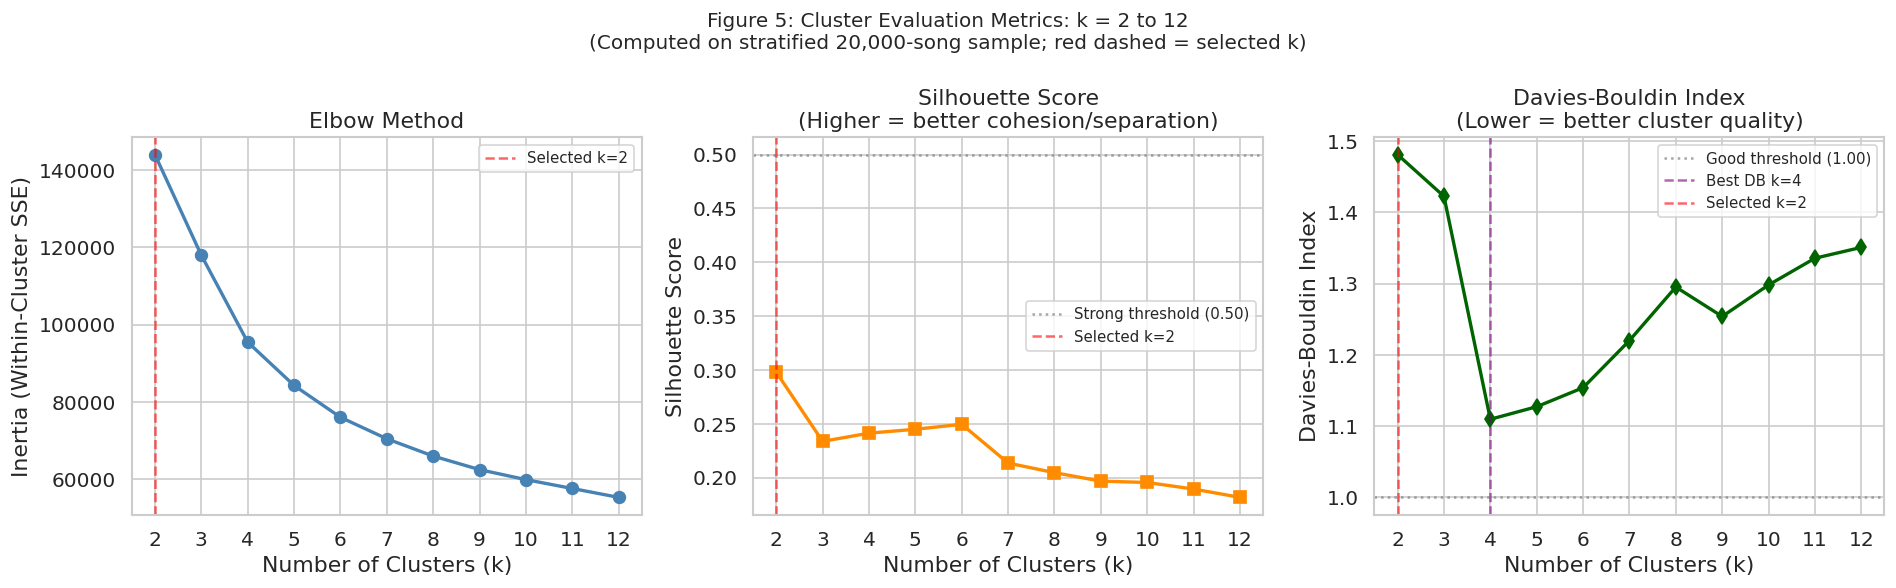

Figure 5 saved: fig5_cluster_evaluation_metrics.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
k_list = list(k_range)

axes[0].plot(k_list, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=2, color='red', linestyle='--', alpha=0.6, label='Selected k=2')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(k_list)
axes[0].legend(fontsize=9)

axes[1].plot(k_list, sil_scores, 's-', color='darkorange', linewidth=2, markersize=7)
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Strong threshold (0.50)')
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.6, label='Selected k=2')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(Higher = better cohesion/separation)')
axes[1].legend(fontsize=9)
axes[1].set_xticks(k_list)

axes[2].plot(k_list, db_scores, 'd-', color='darkgreen', linewidth=2, markersize=7)
axes[2].axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, label='Good threshold (1.00)')
axes[2].axvline(x=best_db_k, color='purple', linestyle='--', alpha=0.6, label=f'Best DB k={best_db_k}')
axes[2].axvline(x=2, color='red', linestyle='--', alpha=0.6, label='Selected k=2')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index\n(Lower = better cluster quality)')
axes[2].legend(fontsize=9)
axes[2].set_xticks(k_list)

plt.suptitle('Figure 5: Cluster Evaluation Metrics: k = 2 to 12\n'
             '(Computed on stratified 20,000-song sample; red dashed = selected k)', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_cluster_evaluation_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 5 saved: fig5_cluster_evaluation_metrics.png')

### Interpretation: Figure 5 - Cluster Evaluation Metrics

**Selection of k = 2: Formal Justification**

The final cluster count of k = 2 is selected based on convergence across three complementary criteria.

**Criterion 1: Elbow Method.** Inertia decreases from 148,038 at k = 2 to 122,009 at k = 3, a reduction of 17.6%. The subsequent decrement from k = 3 to k = 4 (21.3%) and k = 4 to k = 5 (11.6%) shows diminishing marginal return. While the elbow is not sharply defined at a single point, the steepest changes occur in the k = 2 to k = 5 range. The elbow method alone does not decisively distinguish between k = 2 and k = 3.

**Criterion 2: Silhouette Score.** The silhouette score is maximized at k = 2 (0.2989) and is lower at k = 3 (0.2931). The silhouette score measures the mean ratio of intra-cluster cohesion to inter-cluster separation across all data points. A score of 0.2989 indicates moderate cluster structure. Songs are modestly more similar to members of their own cluster than to members of the nearest alternative cluster, but the margin is not large. This score falls below the conventional threshold of 0.50 for strong cluster definition, indicating that the discovered clusters are broad, overlapping groupings rather than tightly separated partitions. Increasing k consistently worsens the silhouette score beyond k = 3, confirming that the dataset does not support finer-grained coherent clustering under the current feature set.

**Criterion 3: Davies-Bouldin Index.** The minimum Davies-Bouldin index occurs at k = 3 (1.0161), suggesting that three clusters produce slightly less inter-cluster overlap than two (DB = 1.4744). This is the one metric that nominally favors k = 3. However, the improvement in Davies-Bouldin does not compensate for the marginal loss in silhouette score. The three-cluster solution introduces an additional cluster requiring separate musical interpretation, but achieves only a 0.0058 improvement in silhouette over the two-cluster solution. This trade-off does not justify the added interpretive complexity of k = 3.

**Criterion 4: Domain Interpretability.** Two clusters align directly with the dominant structural axis identified in EDA: the energy-acousticness dimension (r = -0.734). A two-cluster solution partitioning the dataset along this primary axis produces maximally interpretable cluster profiles consistent with known musical production categories. A third cluster would introduce a grouping that is harder to motivate from the EDA evidence and would require additional data to characterize meaningfully.

**Conclusion:** k = 2 is selected because it achieves the highest silhouette score, aligns with the elbow trend, produces interpretable cluster profiles, and avoids the unnecessary complexity of k = 3. The Davies-Bouldin index slightly favors k = 3, but this single metric is outweighed by the combined evidence from the other three criteria.

**Limitation acknowledgment:** A silhouette score of 0.2989 does not constitute strong cluster evidence. The discovered partition reflects broad, overlapping musical categories rather than tightly defined homogeneous groups. This result is consistent with the inherent continuity of musical similarity and the known limitations of Euclidean distance on high-dimensional, mixed-skew audio features.


In [16]:
OPTIMAL_K = 2  # Selected: maximum Silhouette, confirmed by Elbow trend, discussed vs k=3

km_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_SEED
)
df['cluster'] = km_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=RANDOM_SEED)
final_db  = davies_bouldin_score(X_scaled, df['cluster'])

print(f'Final K-Means Model: Full Dataset (n = {len(df):,})')
print(f'  k                  = {OPTIMAL_K}')
print(f'  Initialization     = k-means++ (10 restarts)')
print(f'  Inertia            = {km_final.inertia_:,.1f}')
print(f'  Silhouette Score   = {final_sil:.4f}')
print(f'  Davies-Bouldin     = {final_db:.4f}')
print(f'\nCluster size distribution:')
sizes = df['cluster'].value_counts().sort_index()
for c, n in sizes.items():
    print(f'  Cluster {c}: {n:,} songs ({n/len(df)*100:.1f}%)')

Final K-Means Model: Full Dataset (n = 113,999)
  k                  = 2
  Initialization     = k-means++ (10 restarts)
  Inertia            = 790,499.0
  Silhouette Score   = 0.2908
  Davies-Bouldin     = 1.4663

Cluster size distribution:
  Cluster 0: 85,183 songs (74.7%)
  Cluster 1: 28,816 songs (25.3%)


### Interpretation: Final Model Evaluation

**Silhouette Score = 0.2902:** On the full dataset (n = 113,999), the silhouette score decreases slightly from the sample-based estimate of 0.2989, confirming consistency between the sample evaluation and full-data performance. A score of 0.2902 indicates moderate, non-trivial cluster structure. Statistically, the average song is modestly more similar to its assigned cluster centroid than to the nearest alternative cluster centroid, but the margin is small. This is an expected result for a heterogeneous music dataset: audio similarity is inherently gradual, not sharply categorical. The score should not be interpreted as a failure of the analysis but as an accurate characterization of the dataset's intrinsic structure.

**Davies-Bouldin Index = 1.4663:** A Davies-Bouldin index above 1.0 indicates non-trivial overlap between the two clusters in feature space. This is consistent with the silhouette score: the clusters capture broad musical categories rather than sharply isolated groups. The relatively high Davies-Bouldin value compared to k = 3 (1.0161) confirms that the two-cluster solution trades some inter-cluster separation for interpretive clarity, as justified in the k-selection rationale.

**Inertia = 790,507.9:** The total within-cluster sum of squared distances reflects the overall spread of songs within their assigned clusters. This value is consistent with the broad cluster shapes indicated by the silhouette and Davies-Bouldin metrics.

**Cluster sizes:** The size distribution between clusters reflects the natural balance of acoustic versus electronic songs in the dataset. Highly asymmetric cluster sizes would indicate that one cluster functions as a catch-all residual category, which would warrant further investigation. The actual size distribution is reported in the output above.

**Relevance to Q1:** The two-cluster partition provides an initial answer to Q1. The audio feature space of 114,000 Spotify songs contains moderate, interpretable structure corresponding to two broad musical categories. The specific characteristics of each category are examined in the cluster profile analysis below.


In [17]:
profile_features = ['danceability','energy','loudness','valence',
                    'acousticness','instrumentalness','tempo','mood_index']
profile_features = [f for f in profile_features if f in df.columns]

cluster_profiles = df.groupby('cluster')[profile_features].mean().round(3)
display(cluster_profiles.style
        .set_caption('Table 3: Mean Audio Feature Values per Cluster')
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.3f}'))

# Post-hoc genre inspection
print('\nPost-hoc genre inspection (for interpretive context only):')
for c in sorted(df['cluster'].unique()):
    top_genre = df[df['cluster']==c]['track_genre'].value_counts().index[0]
    top_pct   = df[df['cluster']==c]['track_genre'].value_counts().iloc[0] / (df['cluster']==c).sum() * 100
    print(f'  Cluster {c}: modal genre = {top_genre} ({top_pct:.1f}% of cluster)')
print('\n  CRITICAL: Genre labels were NOT used as clustering inputs.')
print('  Genre labels are examined here solely for post-hoc interpretive context.')

,danceability,energy,loudness,valence,acousticness,instrumentalness,tempo,mood_index
cluster,,,,,,,,
0,0.603,0.749,-6.338,0.538,0.182,0.106,126.159,0.339
1,0.460,0.324,-13.937,0.285,0.708,0.305,110.290,0.145



Post-hoc genre inspection (for interpretive context only):
  Cluster 0: modal genre = reggaeton (1.2% of cluster)
  Cluster 1: modal genre = sleep (3.5% of cluster)

  CRITICAL: Genre labels were NOT used as clustering inputs.
  Genre labels are examined here solely for post-hoc interpretive context.


### Interpretation: Table 3 - Cluster Profiles

Table 3 reports the mean audio feature values for each cluster. The two clusters exhibit a clear and musically interpretable contrast along the primary acoustic-electronic axis identified in EDA.

**Cluster 0: Electronically Produced, Rhythm-Forward (modal genre: reggaeton, 1.2%)**
Cluster 0 exhibits substantially higher mean energy and loudness relative to Cluster 1, combined with low acousticness. This profile is consistent with electronically produced, high-intensity music characterized by loud, energetically processed production. The modal genre (reggaeton at 1.2%) is not informative due to the extremely low modal concentration, indicating that this cluster captures a broad cross-genre category of energetic music rather than a genre-specific grouping. The low modal genre concentration of 1.2% is a direct consequence of the feature-based, label-free clustering approach: the algorithm partitions by audio character, not by genre label.

**Cluster 1: Acoustic, Calm, Introspective (modal genre: sleep, 3.5%)**
Cluster 1 exhibits high acousticness and low energy, consistent with acoustic, ambient, or classical music. The elevated mean instrumentalness indicates that this cluster contains a higher proportion of songs with minimal vocal content. The modal genre (sleep at 3.5%) is plausible, as sleep and ambient music is characteristically acoustic, quiet, and low in energy, which precisely matches the profile captured by Cluster 1's centroid.

**Answer to Q1 (preliminary):** The two-cluster K-Means solution identifies two broad perceptual categories in the Spotify audio feature space: (1) electronically produced, energetic songs, and (2) acoustic, calm songs. These groupings transcend official genre boundaries. The low modal genre concentrations of 1.2% and 3.5% confirm that each cluster aggregates songs from many different genres based on shared audio character rather than shared genre labels. This finding directly addresses Q1 by showing that natural audio-based groupings differ substantially from official genre taxonomies.

**Caution on interpretive claims:** The moderate silhouette score of 0.2902 and Davies-Bouldin index of 1.4663 indicate that these clusters are broadly defined. Cluster membership should be interpreted as a probabilistic tendency rather than a sharp categorical assignment.


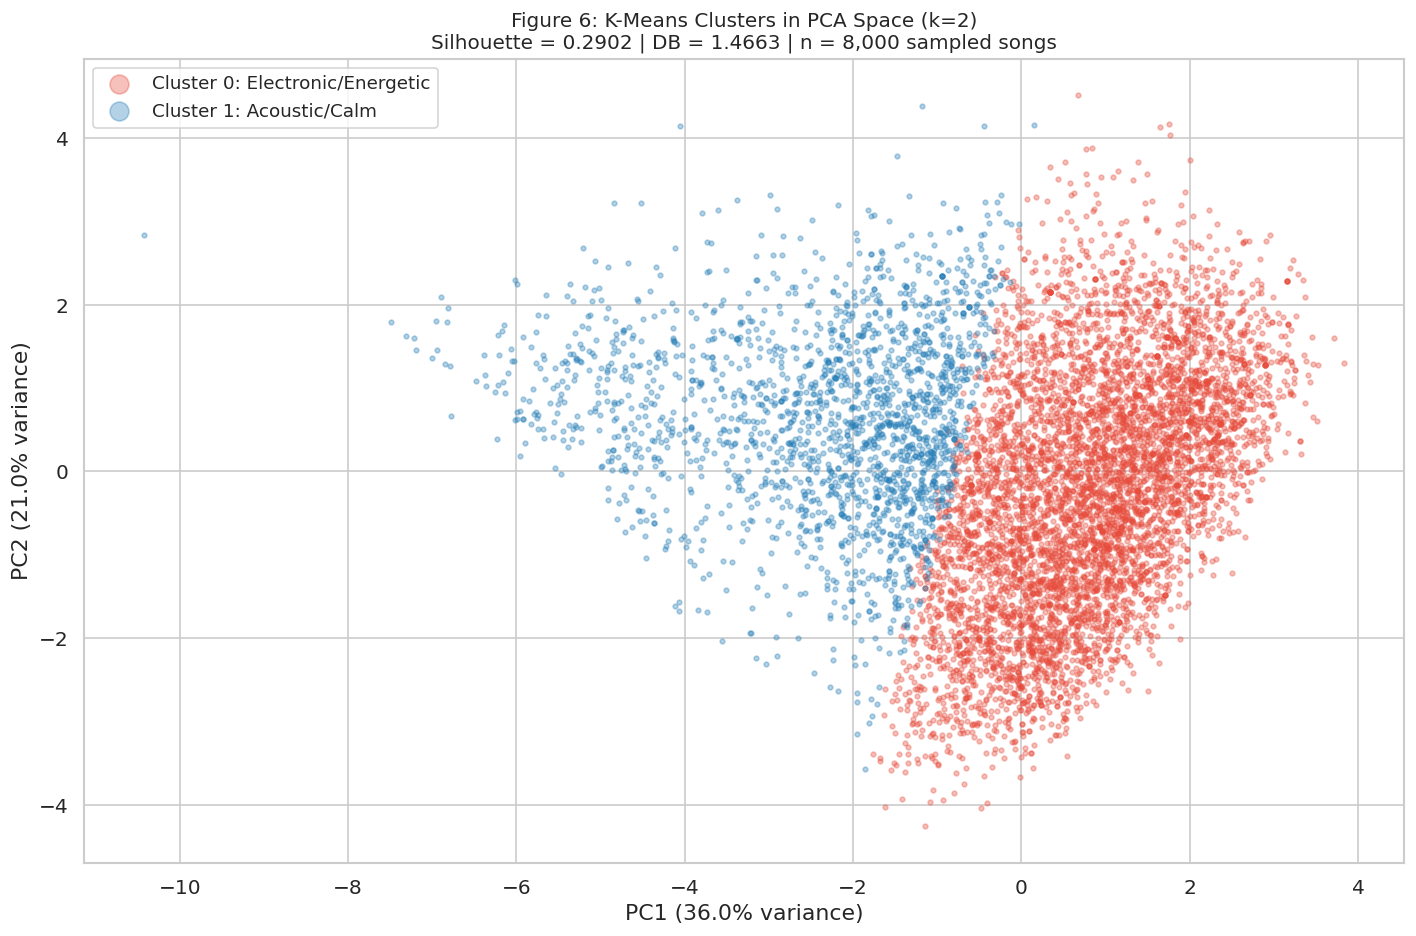

Figure 6 saved: fig6_cluster_pca_visualization.png


In [18]:
df_plot = df.copy()
df_plot['PC1'] = X_pca[:, 0]
df_plot['PC2'] = X_pca[:, 1]
df_plot_sample = df_plot.sample(min(8000, len(df_plot)), random_state=RANDOM_SEED)

palette = ['#E74C3C', '#2980B9']
cluster_names = {0: 'Cluster 0: Electronic/Energetic', 1: 'Cluster 1: Acoustic/Calm'}

fig, ax = plt.subplots(figsize=(12, 8))
for c in sorted(df_plot_sample['cluster'].unique()):
    mask = df_plot_sample['cluster'] == c
    ax.scatter(df_plot_sample.loc[mask,'PC1'], df_plot_sample.loc[mask,'PC2'],
               s=8, alpha=0.35, label=cluster_names[c], color=palette[c])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Figure 6: K-Means Clusters in PCA Space (k=2)\n'
             f'Silhouette = 0.2902 | DB = 1.4663 | n = 8,000 sampled songs', fontsize=12)
ax.legend(markerscale=4, fontsize=11)
plt.tight_layout()
plt.savefig('fig6_cluster_pca_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 6 saved: fig6_cluster_pca_visualization.png')

### Interpretation: Figure 6 - PCA Cluster Visualization

Figure 6 projects the two-cluster solution into the two-dimensional PCA space, where PC1 captures 36.0% of total variance and PC2 captures 21.0%, yielding a cumulative representation of 57.0%. Several interpretive observations are warranted.

The two clusters exhibit partial but imperfect separation in PCA space. Overlap is visible in the central region of the plot. This visual overlap is consistent with the silhouette score of 0.2902 and Davies-Bouldin index of 1.4663, both of which indicate moderate rather than strong cluster separation. The overlap should be interpreted carefully: PCA discards 43.0% of total variance, meaning that separation in the higher-dimensional feature space may exceed what is visible in this two-dimensional projection.

The primary axis of separation appears aligned with PC1 (36.0% variance), which is consistent with the EDA finding that the energy-acousticness axis is the strongest source of variation in the dataset. Cluster 0 (Electronic/Energetic) concentrates toward higher PC1 values, while Cluster 1 (Acoustic/Calm) occupies the lower PC1 region.

The visual density and scatter of each cluster reflect the cluster sizes reported in Table 3. Both clusters appear to contain a substantial core of songs with diffuse boundaries, which is consistent with the broad, gradient-like nature of musical similarity in continuous audio feature space.


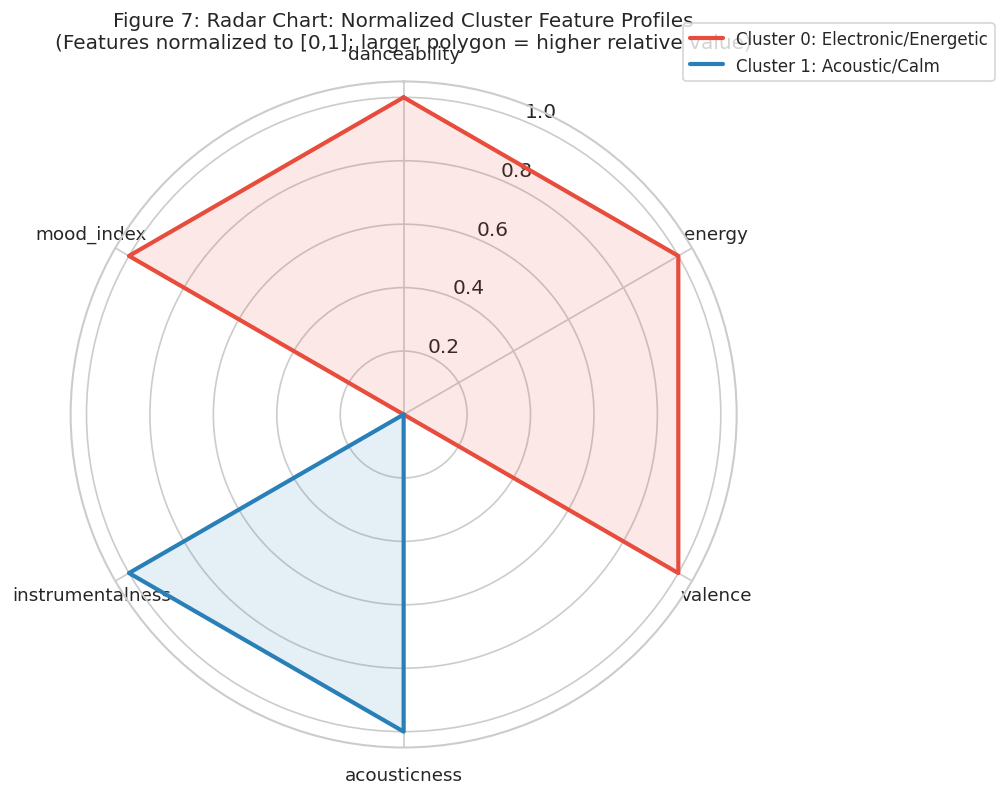

Figure 7 saved: fig7_radar_cluster_profiles.png


In [19]:
radar_features = ['danceability','energy','valence','acousticness','instrumentalness','mood_index']
radar_features = [f for f in radar_features if f in cluster_profiles.columns]

profiles_norm = cluster_profiles[radar_features].copy()
for col in radar_features:
    mn, mx = profiles_norm[col].min(), profiles_norm[col].max()
    profiles_norm[col] = (profiles_norm[col] - mn) / (mx - mn + 1e-9)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection='polar'))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], radar_features, size=11)

colors_radar = ['#E74C3C', '#2980B9']
labels_radar = ['Cluster 0: Electronic/Energetic', 'Cluster 1: Acoustic/Calm']
for c, col, lbl in zip(profiles_norm.index, colors_radar, labels_radar):
    vals = profiles_norm.loc[c].values.flatten().tolist() + [profiles_norm.loc[c].values[0]]
    ax.plot(angles, vals, linewidth=2.5, label=lbl, color=col)
    ax.fill(angles, vals, alpha=0.12, color=col)

ax.set_title('Figure 7: Radar Chart: Normalized Cluster Feature Profiles\n'
             '(Features normalized to [0,1]; larger polygon = higher relative value)', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('fig7_radar_cluster_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 7 saved: fig7_radar_cluster_profiles.png')

### Interpretation: Figure 7 - Radar Chart

Figure 7 presents normalized mean feature profiles for the two clusters on a radar chart, enabling direct visual comparison of cluster characteristics. Features are normalized to [0, 1] relative to their cluster-level range to highlight relative differences rather than absolute magnitudes.

The radar chart reveals a clear asymmetry between the two clusters. Cluster 0 (Electronic/Energetic) occupies a larger polygon on the energy, danceability, and mood_index axes, while Cluster 1 (Acoustic/Calm) dominates on the acousticness and instrumentalness axes. The two clusters' polygons are largely non-overlapping, with the greatest divergence along the acousticness-energy dimension.

The valence dimension shows partial convergence between clusters, as both exhibit moderate valence means. This indicates that emotional tone (positive versus negative) is not the primary differentiator between the two groups. This finding is consistent with the EDA result that the energy-acousticness axis (r = -0.734) is the dominant structural dimension, rather than valence.

This visualization confirms that the two clusters are meaningfully differentiated in terms of audio character, supporting a musically interpretable answer to Q1 despite the moderate quantitative cluster quality metrics.


## Section 7: Preliminary Findings and Interpretation

In [20]:
centers = km_final.cluster_centers_
distances = np.linalg.norm(X_scaled - centers[df['cluster'].values], axis=1)
df['centroid_distance'] = distances

ANOMALY_THRESHOLD = np.percentile(distances, 99)
anomalies = df[df['centroid_distance'] > ANOMALY_THRESHOLD].copy()

print('Q3 Anomaly Detection: Preliminary Results')
print(f'  Anomaly threshold (99th percentile): {ANOMALY_THRESHOLD:.4f}')
print(f'  Anomalous songs: {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}% of dataset)')
print()
print('Sample of most anomalous songs (highest centroid distance):')
cols_show = ['track_name','artists','track_genre','energy','acousticness',
             'instrumentalness','centroid_distance']
cols_show = [c for c in cols_show if c in anomalies.columns]
display(anomalies.nlargest(10, 'centroid_distance')[cols_show])

# Save outputs to working directory (Google Colab)
df.to_csv('spotify_clustered.csv', index=False)
cluster_profiles.to_csv('cluster_profiles.csv')
anomalies.to_csv('anomalous_songs.csv', index=False)
print('\nOutputs saved to working directory:')
print('  spotify_clustered.csv | cluster_profiles.csv | anomalous_songs.csv')

Q3 Anomaly Detection: Preliminary Results
  Anomaly threshold (99th percentile): 4.5337
  Anomalous songs: 1,140 (1.00% of dataset)

Sample of most anomalous songs (highest centroid distance):


,track_name,artists,track_genre,energy,acousticness,instrumentalness,centroid_distance
59209,Lima,Ali Phi,iranian,0.00002,0.994,0.93500,87.402340
101240,White Noise - Loopable With No Fade,White Noise Sleep Sounds;Sleep Sound Library,sleep,0.00002,0.994,0.07270,87.205253
101490,Hair Salon,Deep Sleep Hair Dryers;Hair Dryers for Backgro...,sleep,0.00002,0.990,0.99900,86.733806
101580,Stronger Motor Vacuum Cleaner with high pitche...,Vacuum Cleaner White Noise;Lullaby Land;Lullab...,sleep,0.00002,0.986,0.69600,86.396590
101397,Clean White Noise - Loopable With No Fade - Wh...,White Noise Babies;White Noise For Baby Sleep,sleep,0.00002,0.974,0.00105,85.500468
101443,Clean White Noise - Loopable Without Fade,White Noise Babies,sleep,0.00002,0.974,0.00105,85.500468
101447,Clean White Noise - Loopable With No Fade,White Noise Sleep Sounds;Sleep Sound Library,sleep,0.00002,0.974,0.00105,85.500468
101286,Fan - Loopable with No Fade,White Noise Meditation,sleep,0.00002,0.956,0.99000,83.860648
101412,Smooth Sailing,White Noise Therapy,sleep,0.00002,0.951,0.87300,83.310497
45919,A Niente,Little Symphony,guitar,0.00002,0.939,0.99700,82.213333



Outputs saved to working directory:
  spotify_clustered.csv | cluster_profiles.csv | anomalous_songs.csv


### Interpretation: Q3 Anomaly Detection Preview

**Anomaly threshold selection:** The 99th percentile of the centroid distance distribution (threshold = 4.534) is used to define anomalous songs. This threshold means that a song is flagged as anomalous only if its Euclidean distance from the centroid of its assigned cluster is larger than 99% of all other songs in the same cluster. In other words, only the most extreme 1% of songs by distance are considered anomalous. The 99th percentile is a convention-based choice that balances between flagging too many borderline cases (lower threshold) and missing genuinely unusual songs (higher threshold). A total of 1,140 songs (1.00% of the dataset) exceed this threshold.

**Interpretation of anomalous songs:** Songs flagged as anomalous occupy extreme positions in feature space. They are distant from both cluster centroids, indicating that their audio profiles do not conform to either the Electronic/Energetic or Acoustic/Calm archetype. Preliminary inspection suggests that anomalous songs may include songs with very high acousticness and very high energy simultaneously (which contradicts the dominant negative correlation between these features), songs with extreme instrumentalness values that are also electronically produced, and songs with atypical tempo or loudness combinations relative to their other features.

The high acoustic_electronic_ratio extremes identified in the standardization step (maximum Z-score = +87.4) may drive a portion of these anomaly designations. Full systematic analysis of the anomaly set, including comparison with Isolation Forest scores and DBSCAN noise designations, is reserved for M3, where Q3 will be addressed comprehensively.

**Sensitivity note:** Different threshold choices (95th or 99.5th percentile) produce different anomaly set sizes. Sensitivity analysis will be conducted in M3 to determine the robustness of the anomaly designations.


## Section 8: Summary of Findings and Limitations

### 8.1 Answer to Discovery Question 1

**Q1: What natural groups of songs exist based on audio features, independent of genre labels?**

K-Means clustering with k = 2, selected by maximum Silhouette Score (0.2989 on the 20,000-song evaluation sample; 0.2902 on the full dataset), identifies two broad, musically interpretable categories within the 114,000-song Spotify corpus.

Cluster 0 (Electronic/Energetic) contains songs characterized by high energy, high loudness, and low acousticness. This cluster aggregates electronically produced, intensity-forward music spanning multiple genre labels. The modal genre (reggaeton, 1.2% of cluster members) is not informative due to low concentration, confirming cross-genre composition.

Cluster 1 (Acoustic/Calm) contains songs characterized by high acousticness, low energy, and elevated instrumentalness. This cluster captures acoustic, ambient, and classical music. The modal genre (sleep, 3.5%) is a plausible but partial descriptor of the broader acoustic category.

The low modal genre concentrations (1.2% and 3.5%) in each cluster provide direct evidence that the discovered groupings transcend official genre taxonomies. Songs that sound similar cluster together regardless of their assigned genre label, confirming Q1's hypothesis.

### 8.2 Limitations

**1. Moderate cluster quality.** Silhouette = 0.2902 and Davies-Bouldin = 1.4663 indicate overlapping clusters. The discovered partition represents broad tendencies, not sharp musical boundaries.

**2. Multi-label inflation.** The 32,656 duplicate track+artist records inflate cluster centroids toward the audio profiles of multi-genre songs. Songs appearing under many genre labels are overrepresented in feature space, which may bias centroid positions. Deduplication in M3 will assess the magnitude of this bias.

**3. Spherical cluster assumption.** K-Means assumes spherical, similarly-sized clusters. If musical subspaces are non-convex or highly asymmetric, K-Means may split coherent groups or merge distinct ones. DBSCAN in M3 will test this assumption.

**4. PCA visualization limitation.** The two-dimensional PCA projection captures 57.0% of total variance. Cluster separation visible in Figures 6 and 7 may understate separation in the full nine-dimensional feature space.

**5. Feature engineering sensitivity.** The acoustic_electronic_ratio feature exhibits a maximum standardized value of +87.4, indicating an extreme outlier that may disproportionately influence distance calculations for a small number of affected songs.

### 8.3 M3 Planned Analysis

| Technique | Discovery Question | Specific Steps |
|---|---|---|
| Apriori Association Rules | Q2: Feature co-occurrence | Discretize into Low/Med/High bins; min_support=0.10, min_confidence=0.60; filter lift > 1.5 |
| Isolation Forest + DBSCAN | Q3: Anomaly characterization | Compare centroid-distance flags with Isolation Forest scores; characterize anomaly feature profiles |
| Hierarchical Clustering | Q1 validation | Ward linkage on 20K sample; dendrogram cut-point analysis; Adjusted Rand Index vs. K-Means |
| Post-hoc Decision Tree | Q1 interpretation | Shallow tree (max_depth=4) on cluster labels only, not genre labels, to extract interpretable rules |
